In [2]:
import os
import pickle
import random
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.transforms as mtransforms
from collections import Counter

In [ ]:
with open("schaefer_parcel_counts.pkl", 'rb') as f:
    parcel_voxel_counts = pickle.load(f)
    
with open('/home/zachkaras/fmri_model/analysis/fir/schaefer_parcel_labels.pkl', 'rb') as f:
    schaefer_parcel_labels = pickle.load(f)
    
with open("/tank/home/zachkaras/fmri_model_data/intermediate_results/all_results_regressor+features.pkl", 'rb') as f:
    records = pickle.load(f)
    
with open("/tank/home/zachkaras/fmri_model_data/intermediate_results/participant_means.pkl", 'rb') as f:
    participant_means = pickle.load(f)
    
# inpath = '/data/zachkaras/fmri_model_data/intermediate_results' 
# with open(f"{inpath}/enrichment_analysis_results.pkl", 'rb') as f:
#     enriched_parcels = pickle.load(f)

random.seed(111)

model_labels = {
    'deepseek_6b' : 'DeepSeek 6B',
}

task_labels = {
    'code' : 'Code',
    'prose': 'Prose'
}

demo_data = pd.read_csv("/home/zachkaras/fmri_model/master-survey-data.csv")
participants = os.listdir("midprocess")
participants = sorted([pid for pid in list(jaccards['code'].keys()) if pid in list(jaccards['prose'].keys())])


In [42]:
important_participants = ['117', '125', '121', '108']

def translate_to_region_names(parcel_num, schaefer_labels):
        parcel_num = int(parcel_num)
        if parcel_num <= 200:
            region = f"Left {schaefer_labels['left'][parcel_num]}"
        else:
            region = f"Right {schaefer_labels['right'][parcel_num]}"
        return region

def get_top_five_regions(parcel_dict):
    parcel_dict = dict(sorted(parcel_dict.items(), key= lambda x: x[1], reverse=True))
    return {region : val for i,(region,val) in enumerate(parcel_dict.items()) if i < 5}

def plot_participant_parcels_across_layers(p, model, task, parcel_dict, region_colors, jaccard):
    # Build rows, sorting each layer's regions by score descending
    rows = []
    for _, row in parcel_dict.iterrows():
        layer = str(row['layer'])
        sorted_regions = sorted(row['top_five_regions'].items(), key=lambda x: x[1], reverse=True)[:5]
        for rank, (region, val) in enumerate(sorted_regions):
            rows.append({'layer': layer, 'region': region, 'score': val, 'rank': rank})
    df = pd.DataFrame(rows)
    # print(df)

    layers = sorted(df['layer'].unique(), key=lambda x: int(x.split('_')[1]))
    layer_labels = [x.split('_')[1] for x in layers]

    n_bars = 5
    bar_width = 0.15
    gap = 0.3  # extra space between groups

    fig, ax = plt.subplots(figsize=(14, 8))
    group_centers = []

    for g_idx, layer in enumerate(layers):
        layer_df = df[df['layer'] == layer].sort_values('score', ascending=False)
        n = len(layer_df)
        offsets = np.arange(n) * bar_width - (n - 1) * bar_width / 2
        center = g_idx * (n_bars * bar_width + gap)
        group_centers.append(center)
        for b_idx, (_, r) in enumerate(layer_df.iterrows()):
            ax.bar(center + offsets[b_idx], r['score'], width=bar_width,
                   color=region_colors[r['region']], edgecolor='black',
                   label=r['region'])

    # Deduplicated legend (first occurrence of each region)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title="Region", loc='lower left', fontsize=14)

    ax.set_xticks(group_centers)
    # ax.set_xticklabels(layers, rotation=45, ha='right')
    ax.set_xticklabels(layer_labels, ha='right', fontsize=16)
    ax.set_xlabel("Layer", fontsize=16)
    # ax.set_ylim([0, 25])
    ax.set_ylabel("Voxels Among Top 10K Per Region", fontsize=16)
    ax.set_title(f"Top Regions Modeled Per Layer - Participant {p}\n{model_labels[model]}-{task_labels[task]} - Jaccard Index: {jaccard:.3f}", fontsize=22)
    plt.tight_layout()
    # plt.savefig(f"/data/zachkaras/fmri_model_data/plots/layer_regions-{p}-{task}.png", dpi=200)
    plt.savefig(f"/tank/home/zachkaras/fmri_model_data/plots/layer_regions-{p}-{task}.png", dpi=200)
    plt.show()


def compute_jaccard(df):
    list_of_sets = [set(row['top_five_regions'].keys()) for i,row in df.iterrows()]
    intersection = set.intersection(*list_of_sets)
    union = set.union(*list_of_sets)
    print(intersection)
    print(union)
    return len(intersection) / len(union)
        

In [23]:
all_regions_global = set()
for vip in important_participants:
    mask = ((records['participant'] == vip) & 
            (records['look_ahead'] == 'look_ahead_by_0') &
            (records['ndelays'] == 'ndelays_10') &
            (records['model'] == 'deepseek_6b'))
    for (model, task), df in records[mask].groupby(['model', 'task']):
        temp = df['top_parcels'].apply(lambda row: [translate_to_region_names(el, schaefer_parcel_labels) for el in row])
        df['top_HarvOx_regions'] = temp.apply(lambda row: dict(Counter(row)))
        df['top_five_regions'] = df['top_HarvOx_regions'].apply(lambda row: get_top_five_regions(row))
        for top_five in df['top_five_regions']:
            all_regions_global.update(top_five.keys())

all_regions_global = sorted(all_regions_global)  # sort for deterministic ordering
palette = sns.color_palette("rainbow", len(all_regions_global))
rng = np.random.default_rng(seed=1) # 111 is pretty good
rng.shuffle(palette)
region_colors = {r: palette[i] for i, r in enumerate(all_regions_global)}

In [41]:
# all participants
jaccards = {
    'code' :{},
    'prose':{}
}
for p in participants:
    mask = ((records['participant'] == p) & 
            (records['look_ahead'] == 'look_ahead_by_0') &
            (records['ndelays'] == 'ndelays_10') &
            (records['model'] == 'deepseek_6b'))
    for (model, task), df in records[mask].groupby(['model', 'task']):
        temp = df['top_parcels'].apply(lambda row: [translate_to_region_names(el, schaefer_parcel_labels) for el in row])
        df['top_HarvOx_regions'] = temp.apply(lambda row: dict(Counter(row)))
        df['top_five_regions'] = df['top_HarvOx_regions'].apply(lambda row: get_top_five_regions(row))
        filtered = df[['layer', 'top_five_regions']].copy()
        filtered = filtered.sort_values('layer', key=lambda col: col.map(lambda x: int(x.split('_')[1])))
        print(p)
        jaccard_index = compute_jaccard(filtered)
        jaccards[task][p] = jaccard_index
        # print(p, model, task, jaccard_index)

105
[{'Left Middle Frontal Gyrus', 'Left Lateral Occipital Cortex, superior division', 'Left Superior Frontal Gyrus', 'Left Frontal Pole', 'Right Frontal Pole'}, {'Left Precentral Gyrus', 'Left Middle Frontal Gyrus', 'Left Lateral Occipital Cortex, superior division', 'Left Superior Frontal Gyrus', 'Left Frontal Pole'}, {'Left Precentral Gyrus', 'Left Middle Frontal Gyrus', 'Left Lateral Occipital Cortex, superior division', 'Left Superior Frontal Gyrus', 'Left Frontal Pole'}, {'Left Precentral Gyrus', 'Left Middle Frontal Gyrus', 'Left Lateral Occipital Cortex, superior division', 'Left Superior Frontal Gyrus', 'Left Frontal Pole'}, {'Left Precentral Gyrus', 'Left Middle Frontal Gyrus', 'Left Lateral Occipital Cortex, superior division', 'Left Superior Frontal Gyrus', 'Left Frontal Pole'}, {'Left Middle Frontal Gyrus', 'Left Lateral Occipital Cortex, superior division', 'Left Postcentral Gyrus', 'Left Superior Frontal Gyrus', 'Left Frontal Pole'}, {'Left Middle Frontal Gyrus', 'Left L

In [18]:
for task in ['code', 'prose']:
    mean = np.mean(list(jaccards[task].values()))
    std = np.std(list(jaccards[task].values()))
    print(f"{task_labels[task]} ($\\mu={mean:.3f}$, $\\sigma={std:.3f}$)")
    
t,p = stats.ttest_rel(list(jaccards['code'].values()), list(jaccards['prose'].values()))
print(f"($t={t:.3f}$, ${p:.3f}$)", p)

Code ($\mu=0.647$, $\sigma=0.275$)
Prose ($\mu=0.550$, $\sigma=0.212$)
($t=1.430$, $0.167$) 0.16670932837192473


In [37]:
jaccards

{'code': {'105': 0.5714285714285714,
  '108': 0.42857142857142855,
  '109': 0.6666666666666666,
  '111': 0.42857142857142855,
  '112': 0.6666666666666666,
  '117': 1.0,
  '118': 1.0,
  '119': 0.4444444444444444,
  '121': 0.0,
  '122': 1.0,
  '125': 0.375,
  '129': 1.0,
  '133': 0.5714285714285714,
  '134': 0.4444444444444444,
  '138': 0.42857142857142855,
  '141': 1.0,
  '142': 1.0,
  '144': 0.2857142857142857,
  '150': 1.0,
  '151': 0.6666666666666666,
  '201': 0.5714285714285714,
  '203': 0.6666666666666666,
  '204': 0.6666666666666666},
 'prose': {'105': 0.42857142857142855,
  '108': 0.375,
  '109': 0.5,
  '111': 0.6666666666666666,
  '112': 0.375,
  '117': 0.5714285714285714,
  '118': 0.5714285714285714,
  '119': 0.2857142857142857,
  '121': 0.6666666666666666,
  '122': 0.6666666666666666,
  '125': 0.42857142857142855,
  '129': 0.375,
  '133': 0.42857142857142855,
  '134': 1.0,
  '138': 0.6666666666666666,
  '141': 0.3333333333333333,
  '142': 1.0,
  '144': 0.42857142857142855,
  '

105 0.5714285714285714
108 0.42857142857142855
109 0.6666666666666666
111 0.42857142857142855
112 0.6666666666666666
117 1.0
118 1.0
119 0.4444444444444444
121 0.0
122 1.0
125 0.375
129 1.0
133 0.5714285714285714
134 0.4444444444444444
138 0.42857142857142855
141 1.0
142 1.0
144 0.2857142857142857
150 1.0
151 0.6666666666666666
201 0.5714285714285714
203 0.6666666666666666
204 0.6666666666666666


/tmp/ipykernel_1346653/2049001314.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


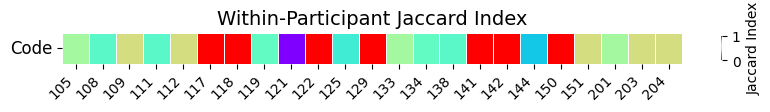

105 0.42857142857142855
108 0.375
109 0.5
111 0.6666666666666666
112 0.375
117 0.5714285714285714
118 0.5714285714285714
119 0.2857142857142857
121 0.6666666666666666
122 0.6666666666666666
125 0.42857142857142855
129 0.375
133 0.42857142857142855
134 1.0
138 0.6666666666666666
141 0.3333333333333333
142 1.0
144 0.42857142857142855
150 1.0
151 0.6666666666666666
201 0.2857142857142857
203 0.5
204 0.42857142857142855


/tmp/ipykernel_1346653/2049001314.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


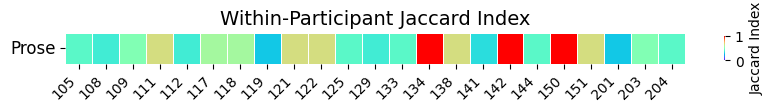

In [36]:
# participants = sorted(
#     set(jaccards['code'].keys()) & set(jaccards['prose'].keys()),
#     key=lambda p: jaccards['code'][p]
# )
participants = sorted([pid for pid in list(jaccards['code'].keys()) if pid in list(jaccards['prose'].keys())])

for task in ['code', 'prose']:
    # print(participants)
    data = [[jaccards[task][p]  for p in participants]]
    # print(data)
    for i,d in enumerate(data[0]):
        print(participants[i], d)
    # fig, ax = plt.subplots(figsize=(max(10, len(participants) * 0.65), 2.5))
    fig, ax = plt.subplots(figsize=(10, 0.4))
    sns.heatmap(
        data,
        # annot=True,
        fmt='.3f',
        cmap='rainbow',
        vmin=0, vmax=1,
        linewidths=0.5,
        linecolor='white',
        ax=ax,
        # annot_kws={'size': 9},
        cbar_kws={'label': 'Jaccard Index', 'shrink': 0.8},
    )
    ax.set_xticks(np.arange(len(participants)) + 0.5)
    ax.set_xticklabels(participants, rotation=45, ha='right', fontsize=10)
    # ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels([task_labels[task]], rotation=0, va='center', fontsize=12)
    ax.set_title('Within-Participant Jaccard Index', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'/tank/home/zachkaras/fmri_model_data/plots/jaccard_vector_heatmap_deepseek6b_{task}.png', dpi=200)
    plt.show()

In [20]:
def calculate_correlation(task):

    performance = participant_means[task]
    jaccard = jaccards[task]

    performance = dict(sorted(performance.items()))
    
    jaccard = dict(sorted(jaccard.items()))
    
    x,y = list(performance.values()), list(jaccard.values())
    print(len(x))
    print(len(y))
    r,p = stats.pearsonr(x,y)
    print(f"{task_labels[task]} ($r={r:.3f}$, $p={p:.3f}$)", p)

    
calculate_correlation('code')
calculate_correlation('prose')



23
23
Code ($r=0.223$, $p=0.306$) 0.305505014798926
23
23
Prose ($r=0.262$, $p=0.228$) 0.22803348204265336


{'Left Precentral Gyrus', 'Left Lateral Occipital Cortex, superior division', 'Left Postcentral Gyrus', 'Left Frontal Pole', 'Right Frontal Pole'}
{'Left Precentral Gyrus', 'Left Lateral Occipital Cortex, superior division', 'Left Postcentral Gyrus', 'Left Frontal Pole', 'Right Frontal Pole'}


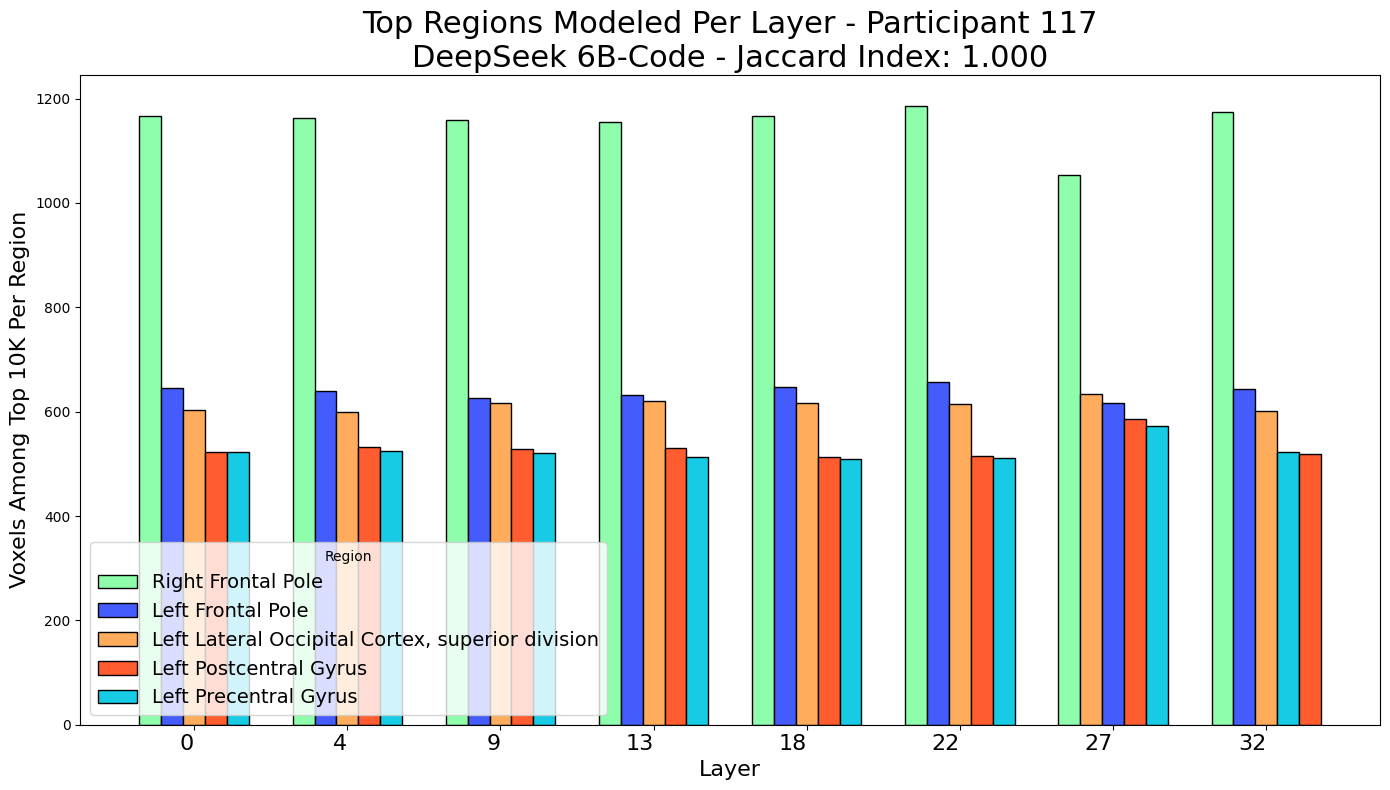

{'Left Lateral Occipital Cortex, superior division', 'Right Lateral Occipital Cortex, superior division', 'Left Frontal Pole', 'Right Frontal Pole'}
{'Right Precentral Gyrus', 'Left Precentral Gyrus', 'Right Lateral Occipital Cortex, superior division', 'Left Lateral Occipital Cortex, superior division', 'Left Occipital Pole', 'Left Frontal Pole', 'Right Frontal Pole'}


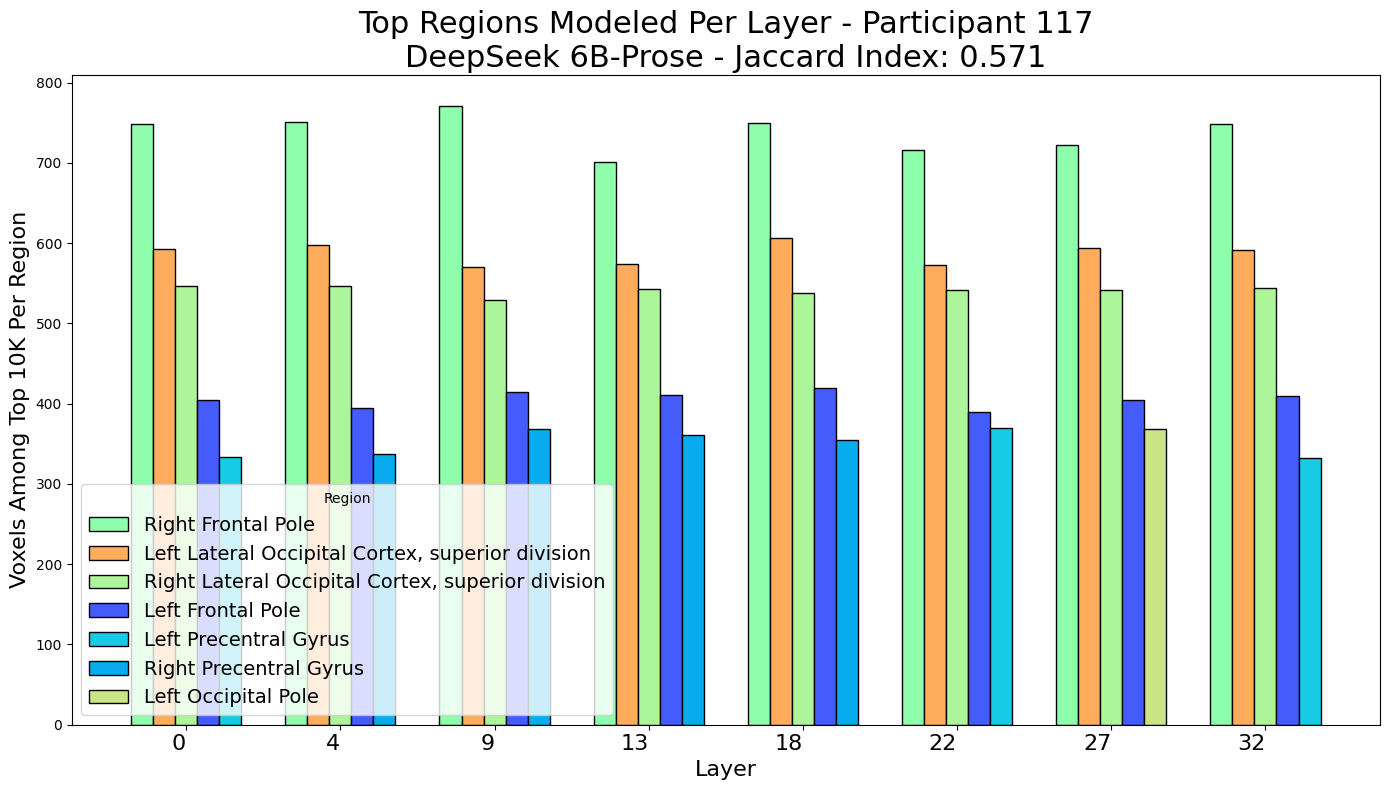

{'Left Lateral Occipital Cortex, superior division', 'Left Frontal Pole', 'Right Frontal Pole'}
{'Right Lateral Occipital Cortex, inferior division', 'Right Lateral Occipital Cortex, superior division', 'Left Middle Frontal Gyrus', 'Left Lateral Occipital Cortex, superior division', 'Right Middle Frontal Gyrus', 'Left Superior Frontal Gyrus', 'Left Frontal Pole', 'Right Frontal Pole'}


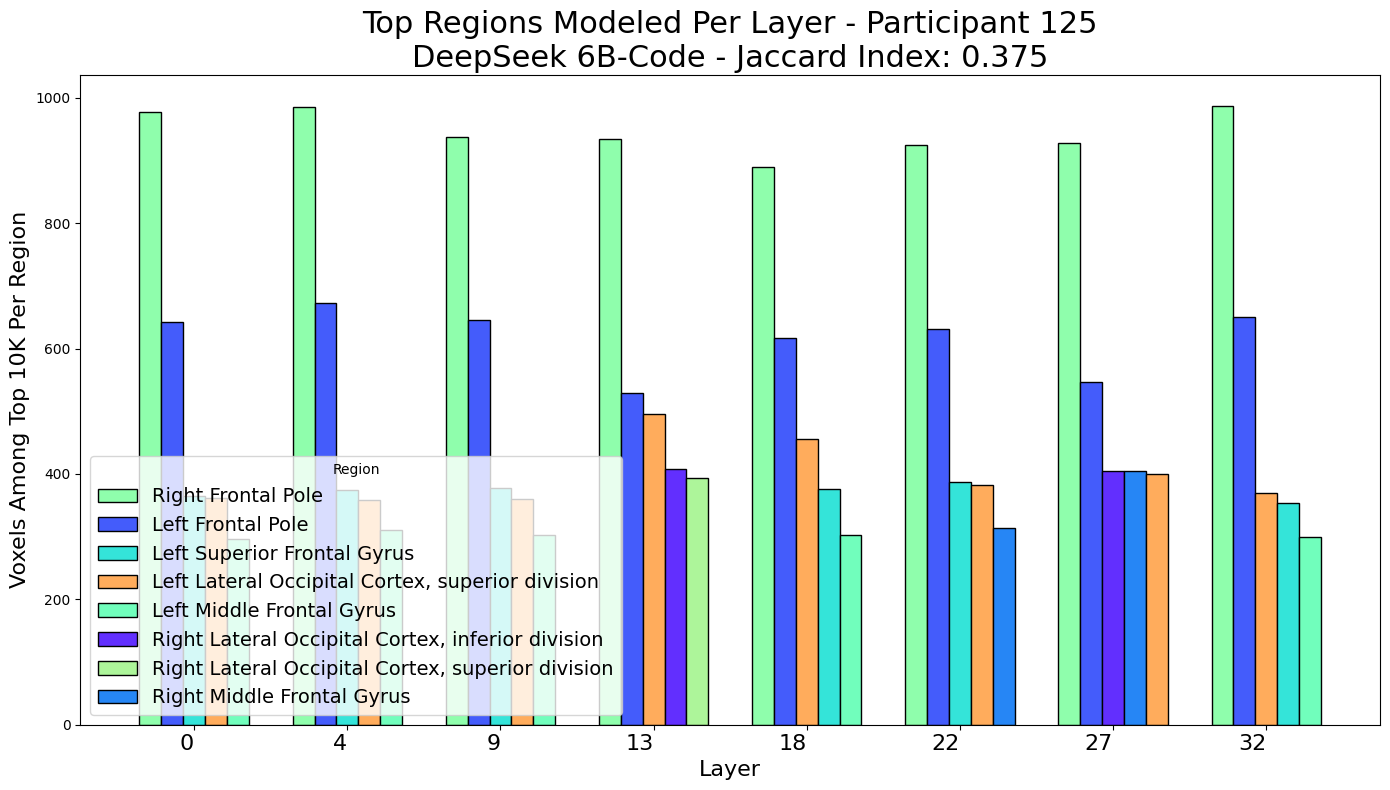

{'Right Frontal Pole', 'Right Lateral Occipital Cortex, inferior division', 'Right Lateral Occipital Cortex, superior division'}
{'Right Precentral Gyrus', 'Right Lateral Occipital Cortex, inferior division', 'Right Lateral Occipital Cortex, superior division', 'Right Occipital Pole', 'Right Middle Temporal Gyrus, temporooccipital part', 'Left Frontal Pole', 'Right Frontal Pole'}


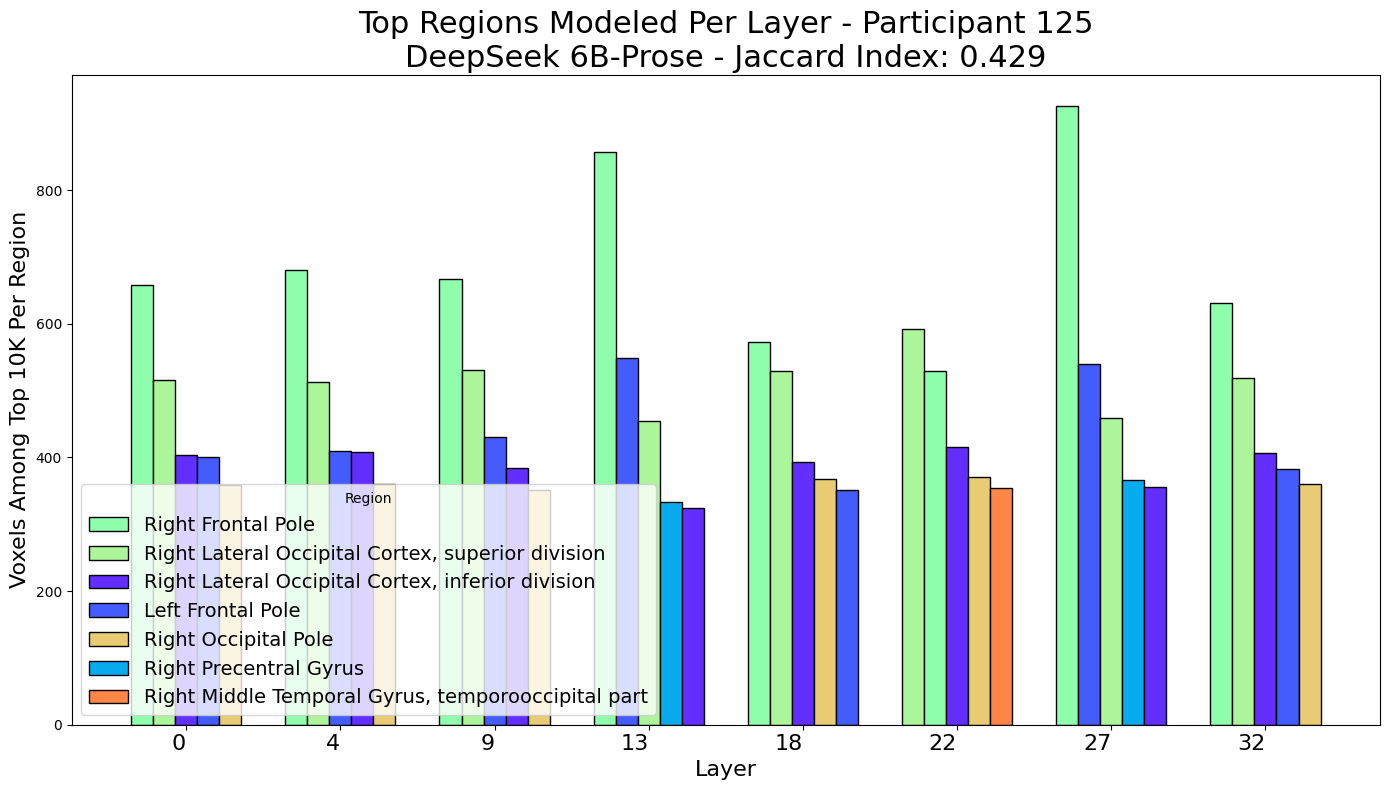

set()
{'Right Precentral Gyrus', 'Left Precentral Gyrus', 'Right Lateral Occipital Cortex, inferior division', 'Left Middle Frontal Gyrus', 'Right Lateral Occipital Cortex, superior division', 'Right Postcentral Gyrus', 'Left Superior Frontal Gyrus', 'Left Occipital Pole', 'Right Precuneous Cortex', 'Left Frontal Pole', 'Right Frontal Pole'}


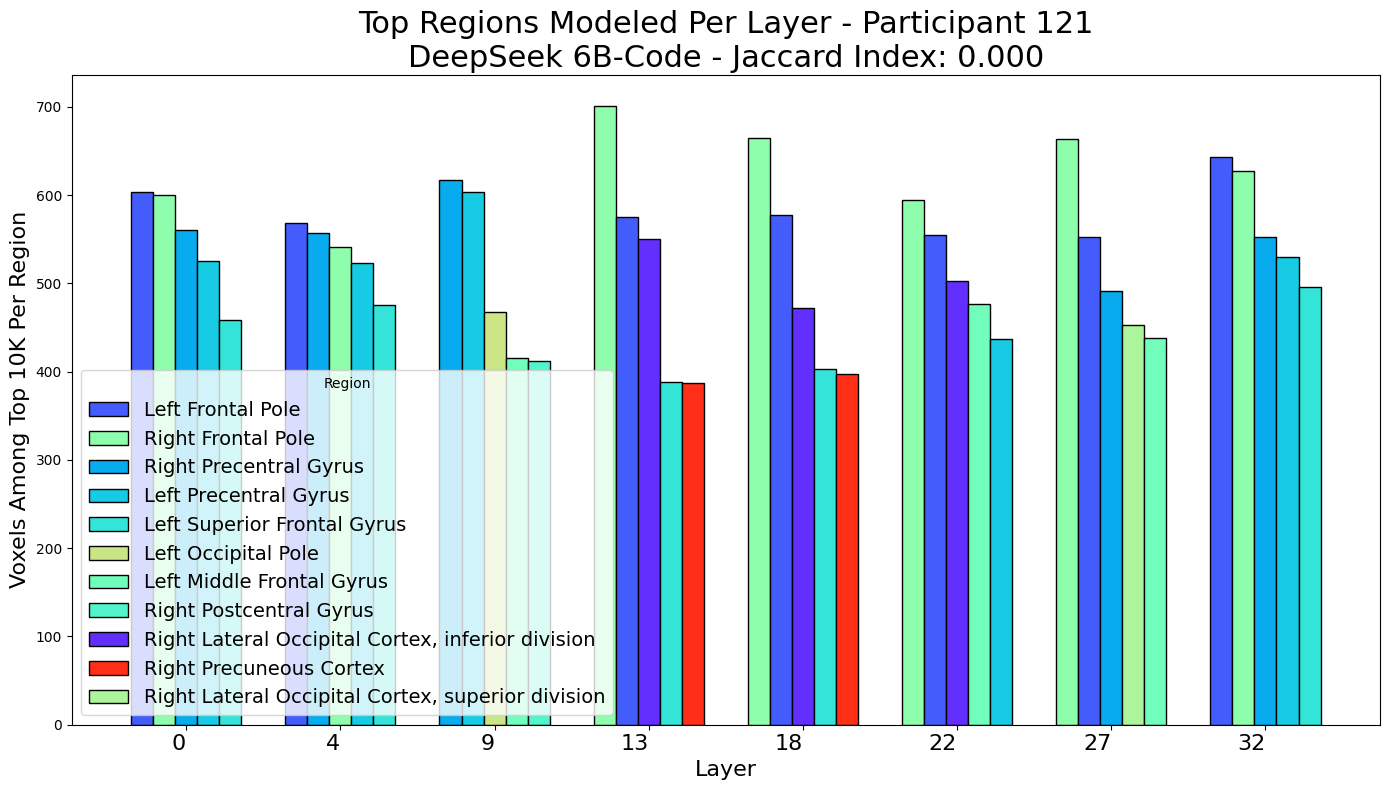

{'Right Middle Frontal Gyrus', 'Right Lateral Occipital Cortex, superior division', 'Left Frontal Pole', 'Right Frontal Pole'}
{'Right Lateral Occipital Cortex, superior division', 'Right Middle Frontal Gyrus', 'Left Postcentral Gyrus', 'Left Frontal Pole', 'Right Precuneous Cortex', 'Right Frontal Pole'}


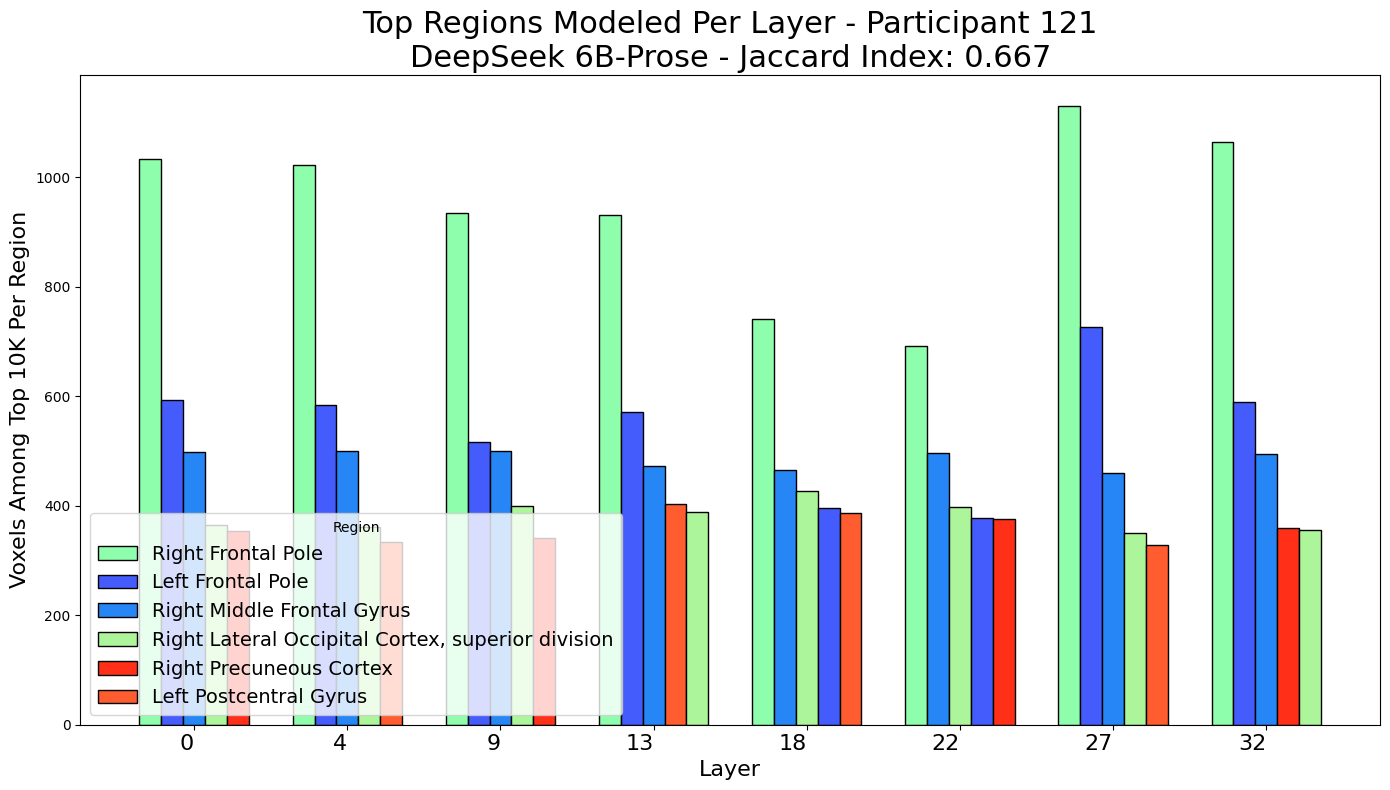

{'Left Lateral Occipital Cortex, superior division', 'Left Precentral Gyrus', 'Left Postcentral Gyrus'}
{'Right Precentral Gyrus', 'Left Precentral Gyrus', 'Right Lateral Occipital Cortex, inferior division', 'Left Lateral Occipital Cortex, superior division', 'Left Postcentral Gyrus', 'Left Frontal Pole', 'Right Frontal Pole'}


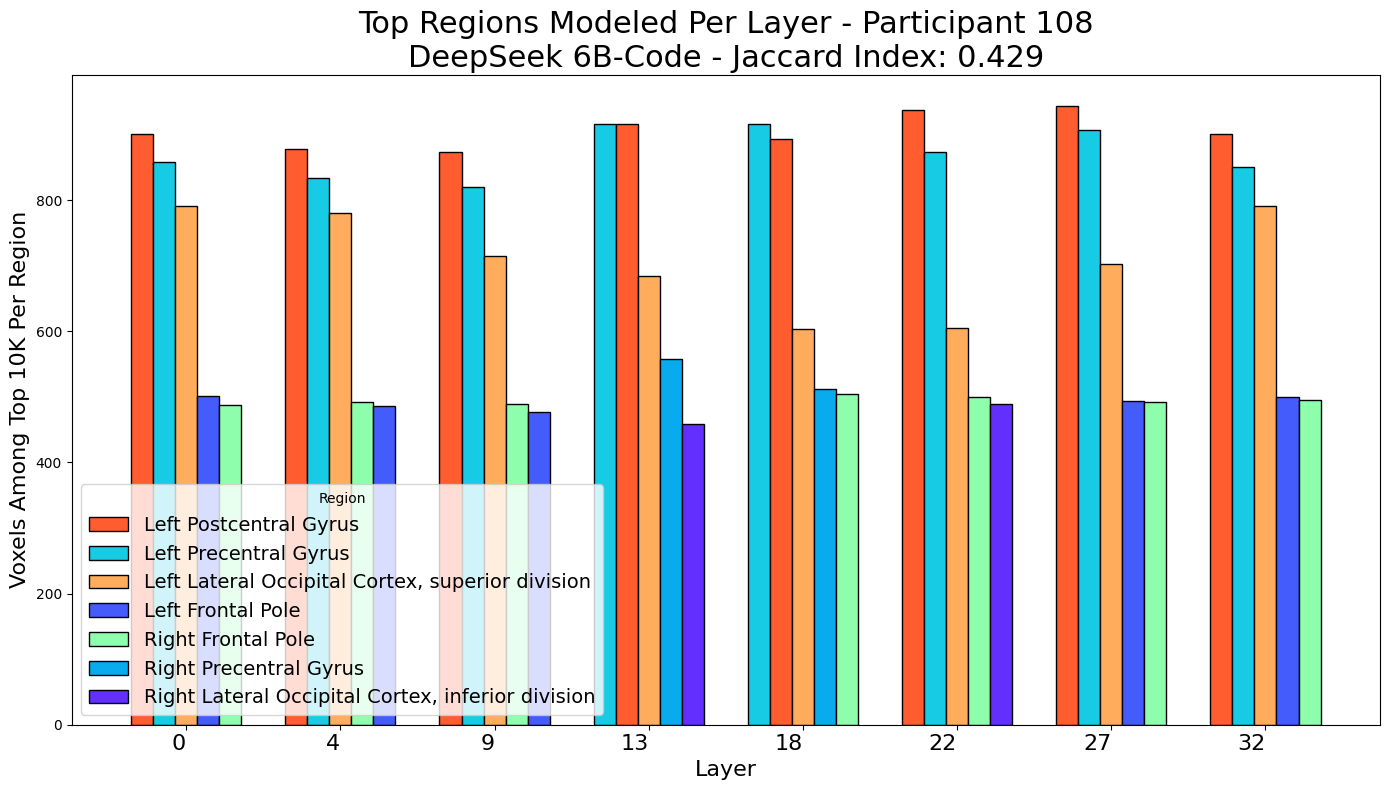

{'Left Lateral Occipital Cortex, superior division', 'Left Frontal Pole', 'Right Frontal Pole'}
{'Right Lateral Occipital Cortex, superior division', 'Left Precentral Gyrus', 'Left Middle Frontal Gyrus', 'Left Lateral Occipital Cortex, superior division', 'Left Postcentral Gyrus', 'Left Superior Frontal Gyrus', 'Left Frontal Pole', 'Right Frontal Pole'}


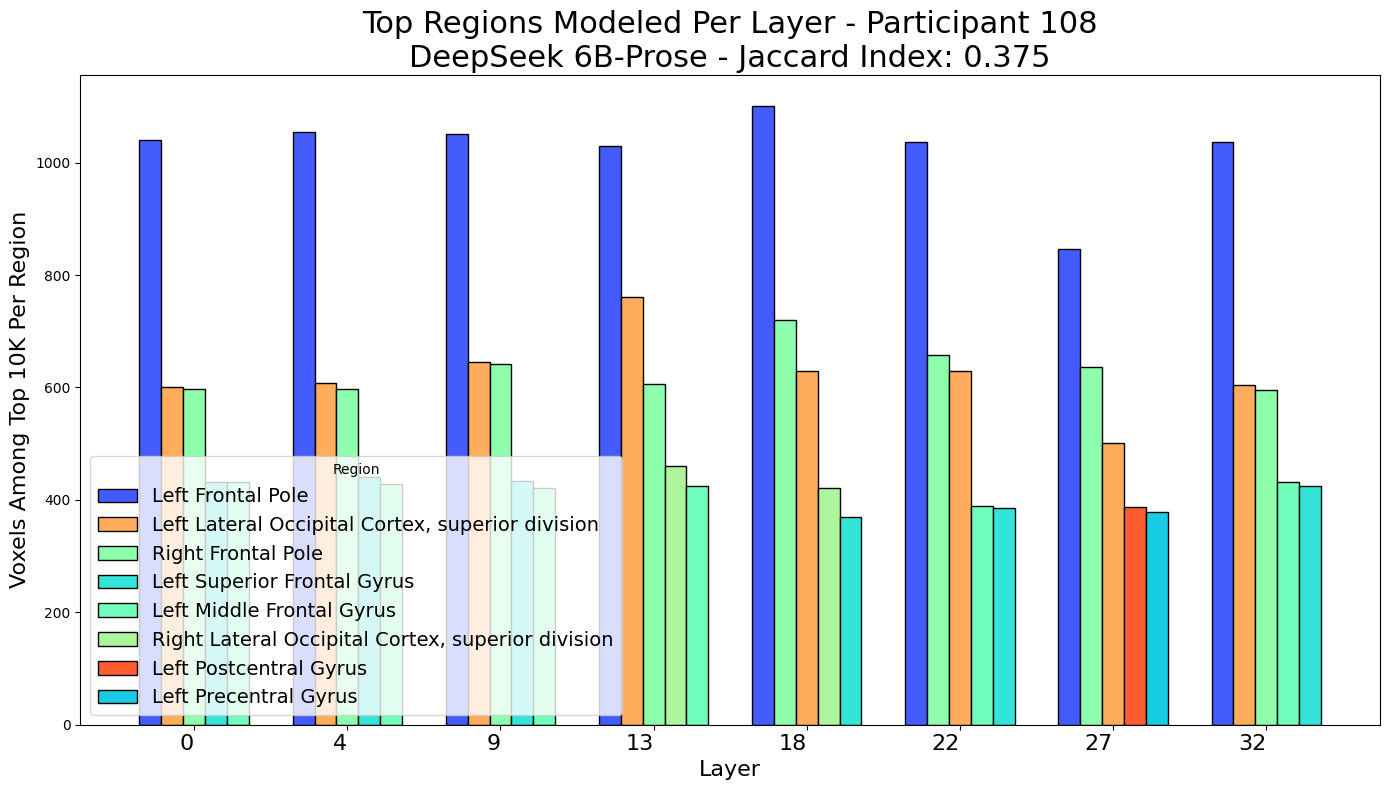

In [43]:

for vip in important_participants:
    mask = ((records['participant'] == vip) & 
            (records['look_ahead'] == 'look_ahead_by_0') &
            (records['ndelays'] == 'ndelays_10') &
            (records['model'] == 'deepseek_6b'))
    for (model, task), df in records[mask].groupby(['model', 'task']):
        temp = df['top_parcels'].apply(lambda row: [translate_to_region_names(el, schaefer_parcel_labels) for el in row])
        df['top_HarvOx_regions'] = temp.apply(lambda row: dict(Counter(row)))
        df['top_five_regions'] = df['top_HarvOx_regions'].apply(lambda row: get_top_five_regions(row))
        filtered = df[['layer', 'top_five_regions']].copy()
        filtered = filtered.sort_values('layer', key=lambda col: col.map(lambda x: int(x.split('_')[1])))
        jaccard_index = compute_jaccard(filtered)
    #     break
    # break
        plot_participant_parcels_across_layers(vip, model, task, filtered, region_colors, jaccard_index)


In [25]:
top_five_regions = {
    'code' : {},
    'prose': {}
}
for p in participants:
    mask = ((records['participant'] == p) & 
            (records['look_ahead'] == 'look_ahead_by_0') &
            (records['ndelays'] == 'ndelays_10') &
            (records['model'] == 'deepseek_6b'))
    for (model, task), df in records[mask].groupby(['model', 'task']):
        # explode by layer
        temp = df['top_parcels'].apply(lambda row: [translate_to_region_names(el, schaefer_parcel_labels) for el in row])
        df['top_HarvOx_regions'] = temp.apply(lambda row: dict(Counter(row)))
        df['top_five_regions'] = df['top_HarvOx_regions'].apply(lambda row: get_top_five_regions(row))
        top_five_regions[task][p] = set(df['top_five_regions'].explode())

In [26]:
with open('typing_counts.pkl', 'rb') as f:
    typing_counts = pickle.load(f)
    

# Add keystroke-based variables to demo_data (separately for code and prose)
for pid_str, tasks in typing_counts.items():
    pid = int(pid_str)
    for task in ['code', 'prose']:
        try:
            total_keys = tasks[task]['total_keys_pressed']
        except:
            print(f"No {task} task for {pid}.")
            continue
        total_backspaces = tasks[task]['total_backspaces']
        mask = demo_data['id'] == pid
        demo_data.loc[mask, f'{task}_total_keystrokes'] = total_keys
        demo_data.loc[mask, f'{task}_editing_rate'] = total_backspaces / total_keys if total_keys > 0 else float('nan')


No prose task for 101.
No code task for 130.


In [31]:
def compute_jaccard_similarity(task, p1, p2):
    p1_regions = top_five_regions[task][p1]
    p2_regions = top_five_regions[task][p2]
    intersection = set.intersection(p1_regions, p2_regions)
    union = set.union(p1_regions, p2_regions)
    return len(intersection) / len(union)

def get_demo_value(p, col):
    """Look up a demo_data value by participant ID string, return inf for NaN (sorts last)."""
    rows = demo_data.loc[demo_data['id'] == int(p), col]
    if rows.empty:
        return float('inf')
    val = rows.values[0]
    return float('inf') if pd.isna(val) else val

def calculate_summary_stats(jaccard_matrix, task, n, participants_sorted):
    lower_triangle = np.full((n,n), np.nan)
    for i,rp in enumerate(jaccard_matrix):
        for j,cp in enumerate(jaccard_matrix[rp]):
            if j >= i:
                continue
            lower_triangle[i][j] = jaccard_matrix.iloc[i,j]
    mean = np.nanmean(lower_triangle)
    std  = np.nanstd(lower_triangle)
    print(f"{task_labels[task]} ($\\mu = {mean:.3f}$, $\\sigma = {std:.3f}$)")
    return lower_triangle,mean,std
    
            
            
def plot_jaccard(task, sort_by, matrix):
    fig, ax = plt.subplots(figsize=(8, 6))                                                                                                                                                                 
    sns.heatmap(matrix, annot_kws={"size":14, "weight":"bold"}, fmt= '', cmap='rainbow', ax=ax)
    ax.set_title(f"{task_labels[task]} — Between-Participant Similarity", fontsize=20)
    ax.set_xlabel("Participant")                                                                                                                                                                            
    ax.set_ylabel("Participant")                                                                                                                                                                   
    plt.tight_layout()       
    plt.savefig(f'/tank/home/zachkaras/fmri_model_data/plots/jaccard_matrix-{task}-{sort_by}.png', dpi=200)                                                                                                                                                                              
    plt.show() 

def create_jaccard_matrix(task, sort_by):
    participants = [pid for pid in list(top_five_regions['code'].keys()) if pid in list(top_five_regions['prose'].keys())]
    # participants = [pid for pid in list(top_five_regions[task].keys())]
    if sort_by in ['code_editing_rate', 'prose_editing_rate']:
        participants_sorted = sorted(participants, key=lambda p: get_demo_value(p, sort_by), reverse=True)
    elif sort_by == 'none':
        participants_sorted = sorted(participants)
        # participants_sorted = participants
        # random.shuffle(participants_sorted)
    else:
        participants_sorted = sorted(participants, key=lambda p: get_demo_value(p, sort_by))

    n = len(participants_sorted)

    jaccard_matrix = pd.DataFrame(
        np.zeros((n, n)),
        index=participants_sorted,
        columns=participants_sorted
    )

    for p1 in participants_sorted:
        for p2 in participants_sorted:
            jaccard_matrix.loc[p1, p2] = compute_jaccard_similarity(task, p1, p2)
    
    lower_triangle, mean,std = calculate_summary_stats(jaccard_matrix, task, n, participants_sorted)
    plot_jaccard(task, sort_by, jaccard_matrix)
    return jaccard_matrix, lower_triangle, mean, std


Code ($\mu = 0.372$, $\sigma = 0.152$)


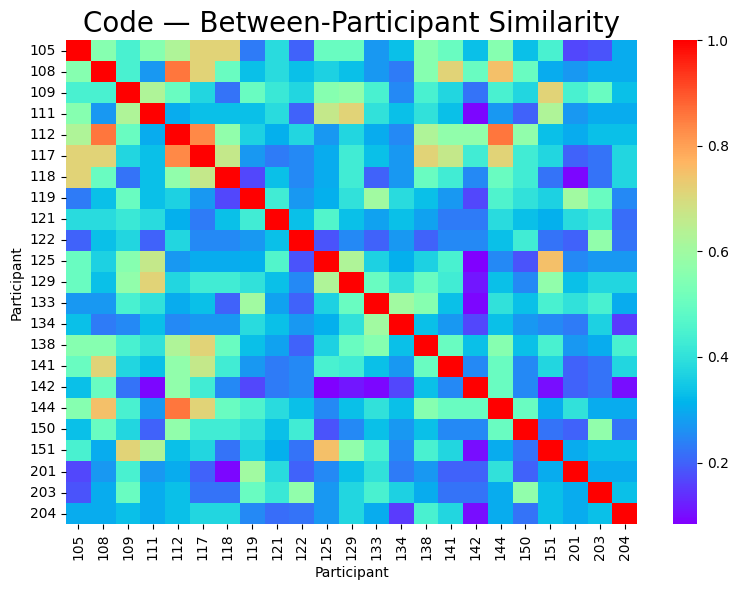

Prose ($\mu = 0.367$, $\sigma = 0.137$)


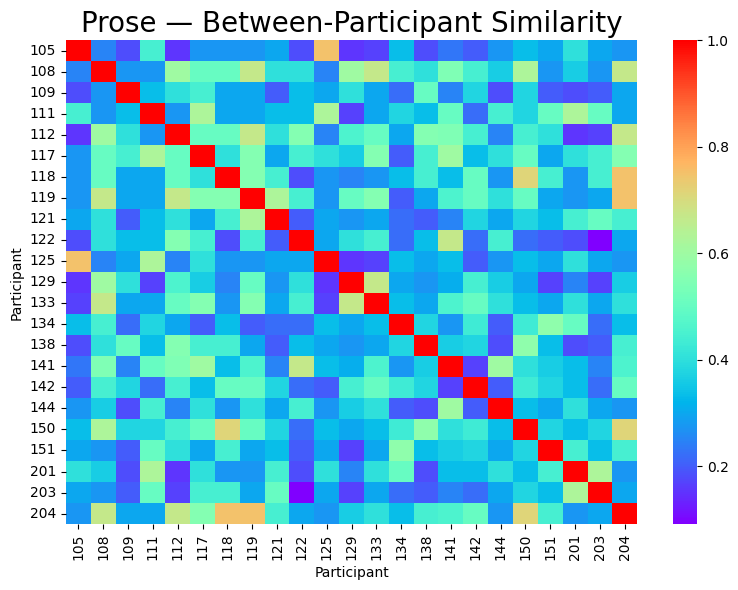

In [32]:
code_jaccard, code_lower, code_mean, code_std  = create_jaccard_matrix('code', sort_by='none')
prose_jaccard, prose_lower, prose_mean, prose_std = create_jaccard_matrix('prose', sort_by='none')

In [ ]:
rows,cols = np.tril_indices(code_jaccard.shape[0], k=-1)
code_vals = code_jaccard.values[rows, cols]
prose_vals = prose_jaccard.values[rows,cols]

t,p = stats.ttest_rel(code_vals, prose_vals)
print(f"($t={t:.3f}$, $p={p:.3f}$)", p)

($t=1.512$, $p=0.132$) 0.13180847235565246


In [ ]:
# create_jaccard_matrix('code', sort_by='age')
# create_jaccard_matrix('prose', sort_by='age')

In [ ]:
# create_jaccard_matrix('code', sort_by='code_editing_rate')
# create_jaccard_matrix('prose', sort_by='prose_editing_rate')

In [ ]:
# create_jaccard_matrix('code', sort_by='semesters_experience')
# create_jaccard_matrix('prose', sort_by='semesters_experience')

In [ ]:

# # Individual plot per row (first 5)
# for idx, row in df.head(5).iterrows():
#     region_counts = row['top_HarvOx_regions']
#     sorted_regions = sorted(region_counts.items(), key=lambda x: x[1], reverse=True)
#     regions, counts = zip(*sorted_regions) if sorted_regions else ([], [])

#     fig, ax = plt.subplots(figsize=(10, 5))
#     ax.bar(range(len(regions)), counts, color=sns.color_palette("tab10", len(regions)))
#     ax.set_xticks(range(len(regions)))
#     ax.set_xticklabels(regions, rotation=45, ha='right', fontsize=8)
#     ax.set_title(f"Row {idx} — {row.get('layer', '')} | Top HarvOx Region Counts")
#     ax.set_ylabel("Count")
#     ax.set_xlabel("Region")
#     ax.set_ylim([0,800])
#     plt.tight_layout()
#     plt.show()

# # Aggregated across all layers
# aggregated = Counter()
# for region_counts in df['top_HarvOx_regions']:
#     aggregated.update(region_counts)

# sorted_agg = sorted(aggregated.items(), key=lambda x: x[1], reverse=True)
# regions, counts = zip(*sorted_agg)

# fig, ax = plt.subplots(figsize=(14, 6))
# ax.bar(range(len(regions)), counts, color=sns.color_palette("tab20", len(regions)))
# ax.set_xticks(range(len(regions)))
# ax.set_xticklabels(regions, rotation=45, ha='right', fontsize=8)
# ax.set_title("Aggregated HarvOx Region Counts Across All Layers")
# ax.set_ylabel("Total Count")
# # ax.set_ylim([0,800])
# ax.set_xlabel("Region")
# plt.tight_layout()
# plt.show()
